## Monitor land cover changes in Pampa

(Region of interest coordinates are chosen to be in Pampa biom, may fall nearby)

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ee.Authenticate()
ee.Initialize(project='your-project')

# AOI: IBGE/MapBiomas Pampa polygon
pampa_aoi = ee.Geometry.Rectangle([-58.0, -34.0, -49.3, -28.0])

START_YEAR, END_YEAR = 2014, 2022

## MapBiomas: annual land-use comparison

In [2]:
mapbiomas_pampa = ee.Image(
    'projects/mapbiomas-public/assets/pampa/collection4/mapbiomas_pampa_collection4_integration_v1'
)

year_a = mapbiomas_pampa.select('classification_2010')
year_b = mapbiomas_pampa.select('classification_2022')

natural_classes = [3, 4, 11, 12]   # Forest, Open Forest, Wetland, Grassland

was_natural = year_a.remap(natural_classes, [1]*len(natural_classes), 0)
still_natural = year_b.remap(natural_classes, [1]*len(natural_classes), 0)
removal_mask = was_natural.And(still_natural.Not()).clip(pampa_aoi)

### Landsat NDVI with real pixel-level cloud masking

In [3]:
def mask_clouds(img):
    qa = img.select('QA_PIXEL')
    cloud_bit = 1 << 3      # bit 3 = cloud
    shadow_bit = 1 << 4     # bit 4 = cloud shadow
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(shadow_bit).eq(0))
    return img.updateMask(mask)

def get_annual_ndvi(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)
    collection = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterDate(start, end)
        .filterBounds(pampa_aoi)
        .filter(ee.Filter.lt('CLOUD_COVER', 50))  # loose scene-level pre-filter, real work done per-pixel below
        .map(mask_clouds)
    )
    def scale_bands(img):
        optical = img.select('SR_B.').multiply(0.0000275).add(-0.2)
        return img.addBands(optical, None, True)
    composite = collection.map(scale_bands).median()
    ndvi = composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return ndvi.multiply(-1000).toInt16().set('system:time_start', start.millis())

years = list(range(START_YEAR, END_YEAR + 1))
ndvi_stack = ee.ImageCollection([get_annual_ndvi(y) for y in years])

### LandTrendr, with proper segment extraction

In [4]:
lt_result = ee.Algorithms.TemporalSegmentation.LandTrendr(
    timeSeries=ndvi_stack,
    maxSegments=6, spikeThreshold=0.9, vertexCountOvershoot=3,
    preventOneYearRecovery=True, recoveryThreshold=0.25,
    pvalThreshold=0.05, bestModelProportion=0.75, minObservationsNeeded=6
)

lt_array = lt_result.select('LandTrendr')

# Keep only vertex years (row 3 == 1), then build "segments" between consecutive vertices
vertex_mask = lt_array.arraySlice(0, 3, 4)
vertices = lt_array.arrayMask(vertex_mask)

left  = vertices.arraySlice(1, 0, -1)   # segment start points
right = vertices.arraySlice(1, 1, None) # segment end points

start_year = left.arraySlice(0, 0, 1)
end_val    = right.arraySlice(0, 2, 3)
start_val  = left.arraySlice(0, 2, 3)
duration   = right.arraySlice(0, 0, 1).subtract(start_year)
magnitude  = end_val.subtract(start_val)   # positive = NDVI got MORE negative-scaled = real vegetation LOSS

# Sort all three arrays by magnitude (descending), keep index 0 = the single worst segment per pixel
neg_key = magnitude.multiply(-1)
greatest_mag  = magnitude.arraySort(neg_key).arraySlice(1, 0, 1)
greatest_year = start_year.arraySort(neg_key).arraySlice(1, 0, 1)
greatest_dur  = duration.arraySort(neg_key).arraySlice(1, 0, 1)

lt_loss_magnitude = greatest_mag.arrayProject([0]).arrayFlatten([['mag']]).divide(1000).multiply(-1).clip(pampa_aoi)
lt_loss_year      = greatest_year.arrayProject([0]).arrayFlatten([['year']]).clip(pampa_aoi)
lt_loss_duration  = greatest_dur.arrayProject([0]).arrayFlatten([['dur']]).clip(pampa_aoi)

### Cross-referencing the two methods

In [8]:
# High-confidence: MapBiomas says removal happened AND LandTrendr independently found a real disturbance
lt_significant = lt_loss_magnitude.lt(-0.15)  # threshold: filters noise
cross_validated_loss = removal_mask.And(lt_significant)

In [9]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(pampa_aoi, 6)
Map.addLayer(cross_validated_loss.selfMask(), {'palette': ['darkred']}, 'High-Confidence Vegetation Loss')
Map.addLayer(removal_mask.selfMask(), {'palette': ['orange']}, 'MapBiomas-only Removal', False)
Map.addLayer(lt_significant.selfMask(), {'palette': ['yellow']}, 'LandTrendr-only Disturbance', False)
Map

Map(center=[-31.04114891682838, -53.650000000000006], controls=(WidgetControl(options=['position', 'transparen…

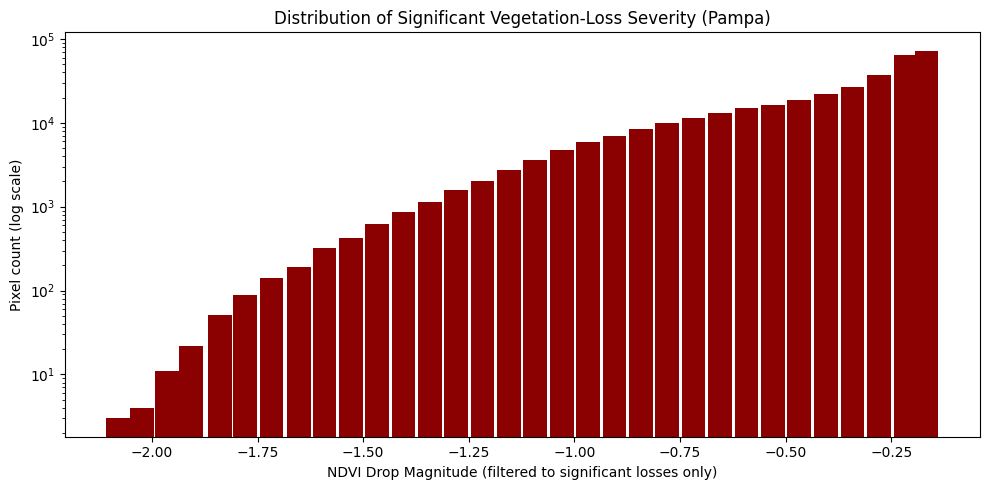

In [10]:
# Area-weighted, filtered, log-scaled magnitude histogram
hist_mag = lt_loss_magnitude.updateMask(lt_significant).reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=20),
    geometry=pampa_aoi,
    scale=500,
    maxPixels=1e10,
    bestEffort=True,
    tileScale=8          # <-- new: splits the computation into smaller memory chunks
).get('mag').getInfo()

plt.figure(figsize=(10, 5))
plt.bar(hist_mag['bucketMeans'], hist_mag['histogram'],
        width=(hist_mag['bucketMeans'][1]-hist_mag['bucketMeans'][0]), color='darkred')
plt.yscale('log')
plt.xlabel('NDVI Drop Magnitude (filtered to significant losses only)')
plt.ylabel('Pixel count (log scale)')
plt.title('Distribution of Significant Vegetation-Loss Severity (Pampa)')
plt.tight_layout()
plt.savefig('pampa_significant_loss_histogram.png', dpi=150)
plt.show()

In the above plot on x-axis, NDVI varies from severe to mild loss in vegetation. The y-axis presents pixels (locations) on log-scale. The most vegetation loss detected is on mild to moderate scale. As severity increased (towards -2.0), pixel value decreased, indicating severe vegetation loss at few places.

                          class  area_ha_2010  area_ha_2022
0              Forest Formation  2.925594e+06  2.980785e+06
1    Open Forest (Savanna-like)  5.951050e+04  4.278803e+04
2                       Wetland  1.396439e+06  1.281487e+06
3                     Grassland  1.890587e+07  1.659465e+07
4                       Pasture  6.644717e+05  1.190470e+06
5  Temporary Crop (Agriculture)  7.881244e+06  9.140331e+06
6             Forest Plantation  1.399619e+06  2.028188e+06
7                Perennial Crop  1.375768e+04  4.496750e+03
8            Non-vegetated area  4.647261e+05  4.653745e+05


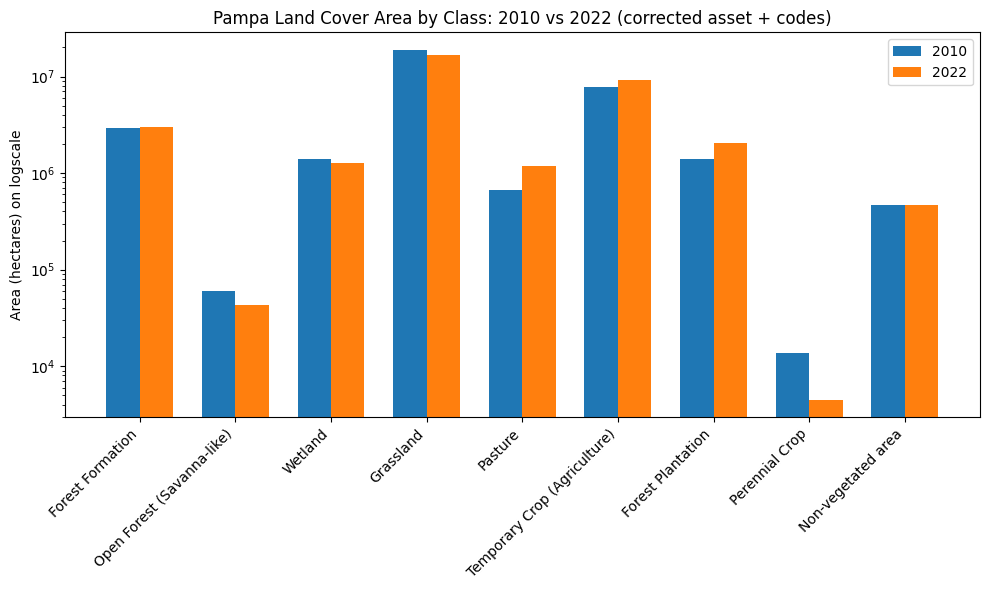

In [11]:
#
class_names = {
    3:  'Forest Formation',
    4:  'Open Forest (Savanna-like)',
    11: 'Wetland',
    12: 'Grassland',
    15: 'Pasture',
    19: 'Temporary Crop (Agriculture)',
    9:  'Forest Plantation',
    36: 'Perennial Crop',
    22: 'Non-vegetated area'
}

pixel_area = ee.Image.pixelArea()

def area_by_class(classification_image, year_label):
    results = {}
    for code, name in class_names.items():
        mask = classification_image.eq(code)
        area_m2 = pixel_area.updateMask(mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=pampa_aoi,
            scale=500,
            maxPixels=1e10,
            tileScale=8          # avoids the memory-limit error from earlier
        ).get('area')
        results[name] = ee.Number(area_m2).divide(10000).getInfo()
    return pd.DataFrame(list(results.items()), columns=['class', f'area_ha_{year_label}'])

df_a = area_by_class(year_a, '2010')
df_b = area_by_class(year_b, '2022')
df_compare = df_a.merge(df_b, on='class')
df_compare.to_csv('pampa_landcover_area_comparison.csv', index=False)
print(df_compare)

x = range(len(df_compare))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], df_compare['area_ha_2010'], width, label='2010')
plt.bar([i + width/2 for i in x], df_compare['area_ha_2022'], width, label='2022')
plt.yscale('log')
plt.xticks(x, df_compare['class'], rotation=45, ha='right')
plt.ylabel('Area (hectares) on logscale')
plt.title('Pampa Land Cover Area by Class: 2010 vs 2022 (corrected asset + codes)')
plt.legend()
plt.tight_layout()
plt.savefig('pampa_area_comparison_chart_corrected.png', dpi=150)
plt.show()

Above plot shows natural grassland has shrank, while land used for farming, livestock, and planted forestry has grown over the years in 2022 compared to 2010.
- Grassland (native vegetation) went down;
- Pasture (land used for livestock) use went up;
- Temporary crops / Agriculture went up;
- Forest Plantation (planted trees, mostly commercial purposes, not natural forest) also increased;
- other Forest Formation, Wetland, Non-vegetated area stayed roughly the same.